# Unsupervised Learning

## Introduction

So far in your machine learning journey, you've worked with **supervised learning** — algorithms that learn from labeled data, where every example comes with the "right answer." But what happens when you don't have labels? What if you just have a massive pile of data and you want to discover hidden patterns, groupings, or structure within it?

That's exactly where **unsupervised learning** comes in. It's one of the most fascinating areas of machine learning because you're essentially asking the algorithm to make sense of data *on its own*, without being told what to look for. Think of it like sorting a box of mixed LEGO pieces by color, shape, or size — nobody tells you the categories, you just figure them out.

In this lesson, you'll learn about two major families of unsupervised techniques:

- **Clustering** — grouping similar data points together
- **Dimensionality Reduction** — compressing high-dimensional data while preserving important structure

By the end, you'll be able to apply several clustering algorithms and dimensionality reduction techniques using scikit-learn, and you'll know when to use each one.

## What Is Unsupervised Learning?

In supervised learning, your dataset looks like `(X, y)` — features and labels. In unsupervised learning, you only have `X`. There are no labels, no target variable, no "correct answer" to learn from.

Instead, unsupervised algorithms try to find **inherent structure** in the data. This might mean:

- Discovering natural groupings (clustering)
- Finding lower-dimensional representations (dimensionality reduction)
- Detecting anomalies or outliers
- Learning the underlying probability distribution

Unsupervised learning is incredibly useful in the real world. Customer segmentation, anomaly detection in fraud prevention, topic modeling in text, and compressing images — all of these rely on unsupervised techniques.


## Clustering: Finding Groups in Data

Clustering is the task of partitioning data into groups (called **clusters**) so that data points within the same group are more similar to each other than to those in other groups. Let's explore the most important clustering algorithms.

### K-Means Clustering

K-Means is probably the most well-known clustering algorithm, and for good reason — it's simple, fast, and often effective. Here's how it works:

1. **Choose K** — the number of clusters you want
2. **Initialize** K random centroids (cluster centers)
3. **Assign** each data point to the nearest centroid
4. **Update** each centroid to the mean of its assigned points
5. **Repeat** steps 3–4 until centroids stop moving (convergence)

The algorithm minimizes the **within-cluster sum of squares (WCSS)** — essentially trying to make clusters as tight as possible.

$$
\mathrm{WCSS} = \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} \|\mathbf{x} - \boldsymbol{\mu}_k\|^2
$$

where $C_k$ is the set of points assigned to cluster $k$ and $\boldsymbol{\mu}_k$ is that cluster's centroid.

Let's see K-Means in action using the Wine dataset from scikit-learn:


In [7]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = load_wine()
X = data.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")
print(f"Unique labels: {set(labels)}")
print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")


Cluster centers shape: (4, 13)
Unique labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}
Inertia (WCSS): 1175.43


Notice that we **standardize** the features first — this is critical for K-Means because it uses Euclidean distance, and features on different scales would dominate the distance calculations.

#### The Elbow Method

One of the trickiest parts of K-Means is choosing the right value of K. The **elbow method** helps by plotting WCSS against different values of K:


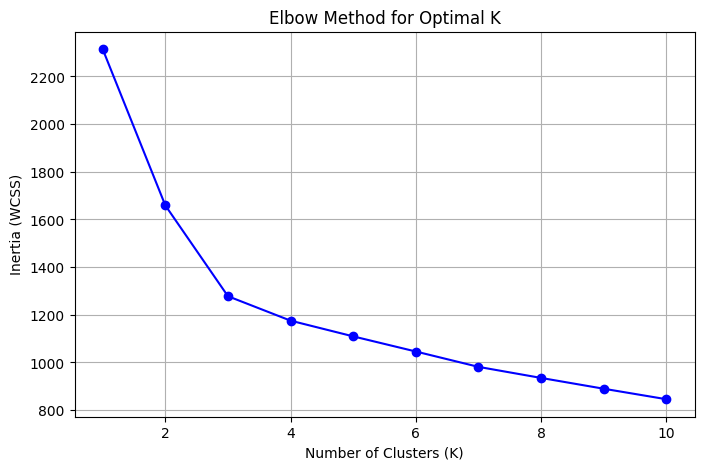

In [8]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, "bo-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()


You're looking for the "elbow" — the point where adding more clusters stops providing significant improvement. The curve bends, and that bend is your best K.


#### Silhouette Score

The **silhouette score** gives you another way to evaluate clustering quality. For each point, it measures how similar it is to its own cluster compared to the nearest neighboring cluster. Scores range from -1 to 1:

- **Close to 1**: Well-clustered
- **Close to 0**: On the border between clusters
- **Negative**: Probably assigned to the wrong cluster

For a sample $i$, with $a(i)$ the mean distance to other points in the same cluster and $b(i)$ the mean distance to points in the **nearest** other cluster, the silhouette is

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}
$$

The reported score is the mean $s(i)$ over all points.


In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score: {score:.3f}")


Silhouette Score: 0.260


#### K-Means Limitations

K-Means is great, but it has some important limitations to keep in mind:

- You must **specify K** in advance
- Assumes clusters are **spherical** and roughly equal in size
- Sensitive to **initial centroid placement** (use `n_init` to mitigate)
- Sensitive to **outliers** — a single extreme point can pull a centroid off course
- Only finds **convex clusters** — it can't handle complex shapes

### Hierarchical Clustering

What if you don't want to commit to a specific number of clusters upfront? **Hierarchical clustering** builds a tree of clusters, and you can choose where to "cut" the tree to get your desired number of groups.

The most common approach is **agglomerative** (bottom-up) clustering:

1. Start with each data point as its own cluster
2. Merge the two closest clusters
3. Repeat until everything is in one cluster

The result is a **dendrogram** — a tree-like diagram showing the merging history:


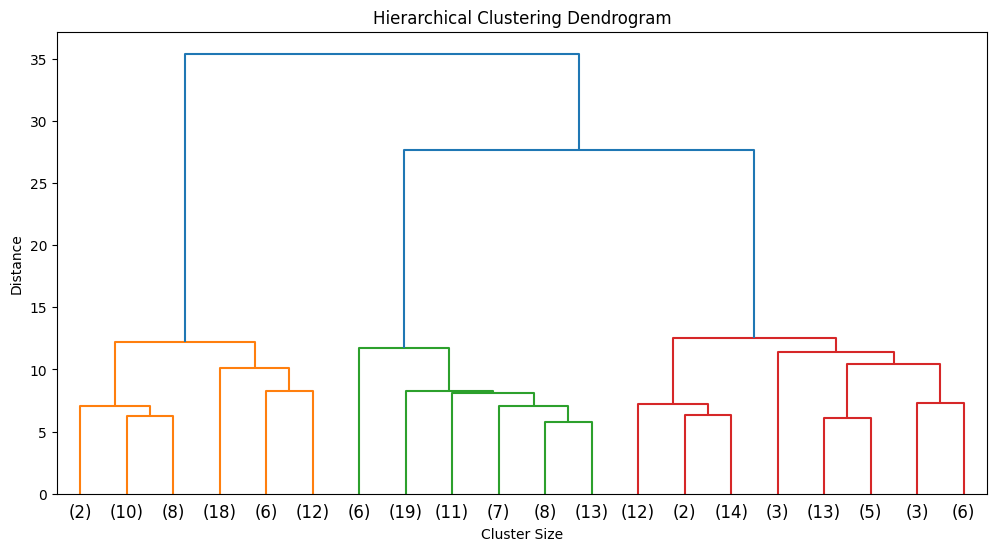

In [11]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()


#### Linkage Methods

How do you define "closest" when merging clusters? That depends on your **linkage method**:

- **Ward** — minimizes the total within-cluster variance (default, often best)
- **Complete** — uses the maximum distance between points in two clusters
- **Average** — uses the average distance between all pairs of points
- **Single** — uses the minimum distance (can produce long, "chain-like" clusters)


In [12]:
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

print(f"Cluster sizes: {np.bincount(agg_labels)}")


Cluster sizes: [58 56 64]


Hierarchical clustering is excellent for exploratory analysis and when you want to visualize the structure of your data at multiple levels of granularity.

### DBSCAN: Density-Based Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) takes a fundamentally different approach: instead of assuming clusters are spherical, it finds regions of **high density** separated by regions of low density.

DBSCAN has two key parameters:

- **epsilon (eps)** — the radius of the neighborhood around each point
- **min_samples** — the minimum number of points required to form a dense region

The algorithm classifies each point as:

- **Core point** — has at least `min_samples` neighbors within `eps`
- **Border point** — within `eps` of a core point but not itself a core point
- **Noise point** — neither core nor border (labeled as -1)


In [18]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")


Number of clusters: 1
Number of noise points: 24


What makes DBSCAN special:

- **No need to specify K** — the algorithm finds the number of clusters automatically
- **Handles arbitrary shapes** — can find clusters that K-Means would miss
- **Identifies noise/outliers** explicitly
- **Robust to outliers** — noise points don't affect cluster formation

The main challenge is tuning `eps` and `min_samples`. A **k-distance plot** can help you choose `eps`:


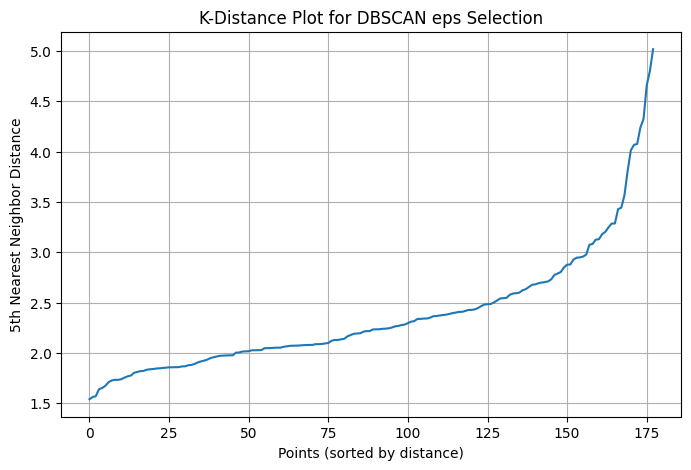

In [15]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel("Points (sorted by distance)")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.grid(True)
plt.show()


Look for the "elbow" in this curve — that's a good starting point for `eps`.


### Gaussian Mixture Models (GMMs)

While K-Means assigns each point to exactly one cluster (hard assignment), **Gaussian Mixture Models** provide **soft clustering** — each point gets a probability of belonging to each cluster.

GMMs assume that the data was generated by a mixture of several Gaussian (normal) distributions. The algorithm uses the **Expectation-Maximization (EM)** algorithm to find the parameters of these Gaussians:

1. **E-step (Expectation)**: Calculate the probability that each point belongs to each Gaussian
2. **M-step (Maximization)**: Update the Gaussian parameters (mean, covariance) based on these probabilities
3. Repeat until convergence


In [19]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

gmm_labels = gmm.predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

print(f"Cluster assignment for first sample: {gmm_labels[0]}")
print(f"Probabilities for first sample: {gmm_probs[0].round(3)}")


Cluster assignment for first sample: 2
Probabilities for first sample: [0. 0. 1.]


The soft assignment is one of GMM's biggest advantages. Instead of "this customer belongs to segment A," you get "this customer has a 70% chance of being in segment A, 25% in B, and 5% in C."

#### BIC for Model Selection

How many components (clusters) should you use? The **Bayesian Information Criterion (BIC)** helps you decide by balancing model fit against complexity:


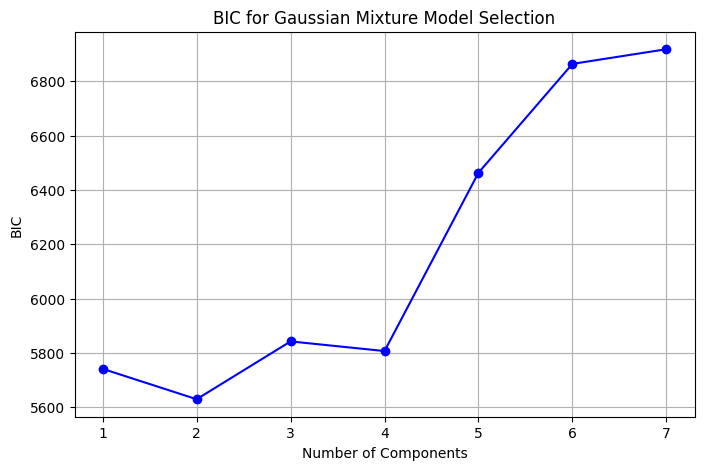

In [20]:
bics = []
n_range = range(1, 8)

for n in n_range:
    gm = GaussianMixture(n_components=n, random_state=42)
    gm.fit(X_scaled)
    bics.append(gm.bic(X_scaled))

plt.figure(figsize=(8, 5))
plt.plot(n_range, bics, "bo-")
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("BIC for Gaussian Mixture Model Selection")
plt.grid(True)
plt.show()


Lower BIC is better. Look for the point where BIC stops decreasing significantly.

For a fitted model with maximized log-likelihood $\hat{\ell}$, number of estimated parameters $p$, and sample size $n$,

$$
\mathrm{BIC} = -2\, \hat{\ell} + p \ln n
$$

(smaller is better; the penalty term $p\ln n$ discourages overly complex mixtures).

Now that you have a solid understanding of clustering, let's shift gears to the second major family of unsupervised learning: dimensionality reduction.

## Dimensionality Reduction: Compressing Your Data

High-dimensional data is everywhere — images, text, genomics, sensor data. But working in high dimensions comes with problems: visualization is impossible beyond 3D, distances become less meaningful (the "curse of dimensionality"), and models can overfit.

**Dimensionality reduction** techniques transform your data from a high-dimensional space to a lower-dimensional one while preserving as much important structure as possible.

### PCA: Principal Component Analysis

PCA is the workhorse of dimensionality reduction. It finds the directions (called **principal components**) along which your data varies the most, and projects the data onto these directions.

The intuition: imagine a cloud of 3D data points that's shaped like a flat pancake. PCA would find that the pancake lies mostly in a 2D plane and project everything onto that plane — capturing most of the variation while dropping the thin dimension.

Mathematically, PCA uses the (centered) data covariance matrix $\mathbf{\Sigma}$. The principal components are the **eigenvectors** $\mathbf{v}_j$ and the variance along each is the corresponding **eigenvalue** $\lambda_j$:

$$
\mathbf{\Sigma}\, \mathbf{v}_j = \lambda_j \, \mathbf{v}_j
$$

Equivalently, the $\mathbf{v}_j$ are the directions of maximum variance subject to orthogonality; **eigenvalues** $\lambda_j$ tell you how much variance each component captures.

Let's use PCA on the Digits dataset to reduce 64 dimensions to 2 for visualization:


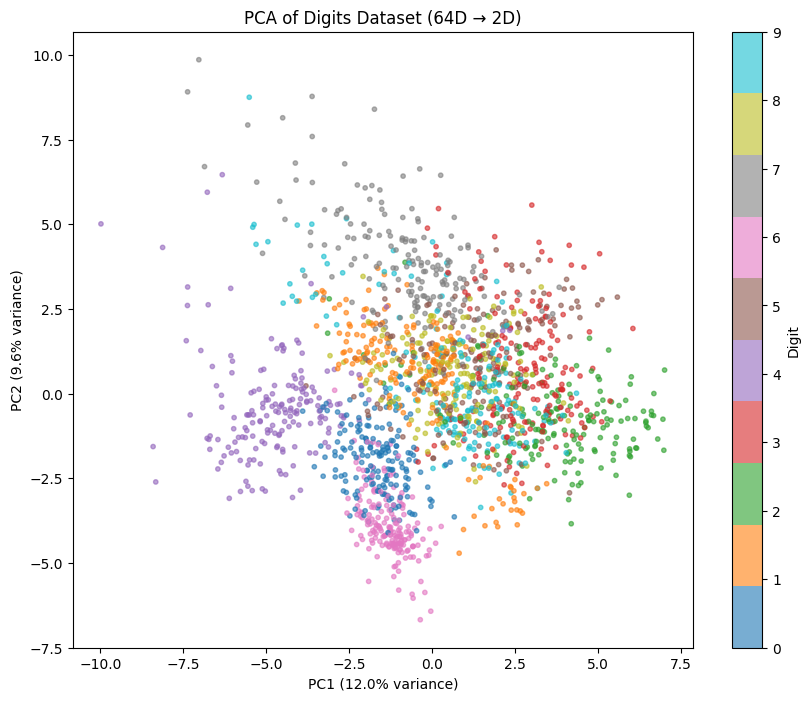

In [21]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_digits_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits, cmap="tab10", alpha=0.6, s=10)
plt.colorbar(scatter, label="Digit")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA of Digits Dataset (64D → 2D)")
plt.show()


#### Choosing the Number of Components

The **explained variance ratio** tells you how much information each component captures:


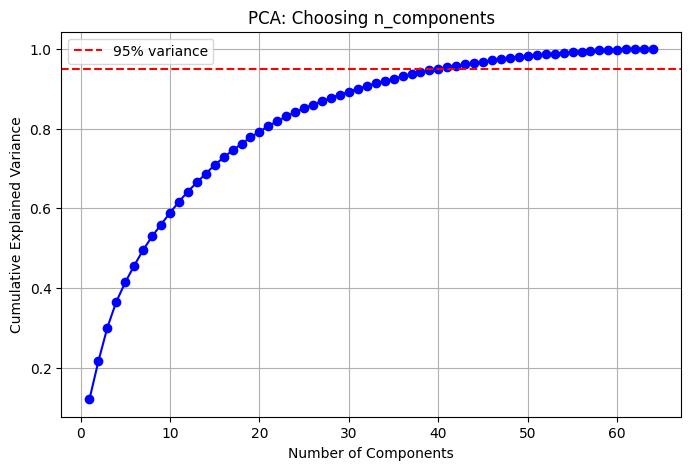

Components needed for 95% variance: 40


In [22]:
pca_full = PCA()
pca_full.fit(X_digits_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, "bo-")
plt.axhline(y=0.95, color="r", linestyle="--", label="95% variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Choosing n_components")
plt.legend()
plt.grid(True)
plt.show()

n_95 = (cumulative_variance >= 0.95).argmax() + 1
print(f"Components needed for 95% variance: {n_95}")


A common rule of thumb: keep enough components to explain **95%** of the variance. This often gives you dramatic compression — going from 64 dimensions down to maybe 25 or so.

### t-SNE: t-Distributed Stochastic Neighbor Embedding

While PCA is great for linear relationships, **t-SNE** excels at revealing **non-linear structure** in your data. It's particularly popular for visualization because it tends to create visually appealing, well-separated clusters.

t-SNE works by:

1. Computing pairwise similarities between points in high-dimensional space
2. Computing pairwise similarities in low-dimensional space (typically 2D)
3. Minimizing the difference between these two similarity distributions

The key parameter is **perplexity**, which roughly controls how many neighbors each point considers. Think of it as a smooth measure of the effective number of neighbors:


In [23]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_digits_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_digits, cmap="tab10", alpha=0.6, s=10)
plt.colorbar(scatter, label="Digit")
plt.title("t-SNE of Digits Dataset")
plt.show()


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

**Important caveats about t-SNE:**

- It's primarily for **visualization** (2D or 3D), not for preprocessing
- The **axes have no interpretable meaning** — you can't say "PC1 explains X% variance"
- **Distances between clusters can be misleading** — cluster sizes and gaps don't reflect real distances
- **Non-deterministic** — different runs can produce different layouts (use `random_state`)
- **Doesn't scale well** to very large datasets (consider using PCA first to reduce to ~50 dimensions)
- Perplexity typically works best between **5 and 50**

### MDS: Multidimensional Scaling

**Multidimensional Scaling (MDS)** focuses on preserving the **pairwise distances** between points. If two points were far apart in the original space, they should be far apart in the reduced space too.


/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


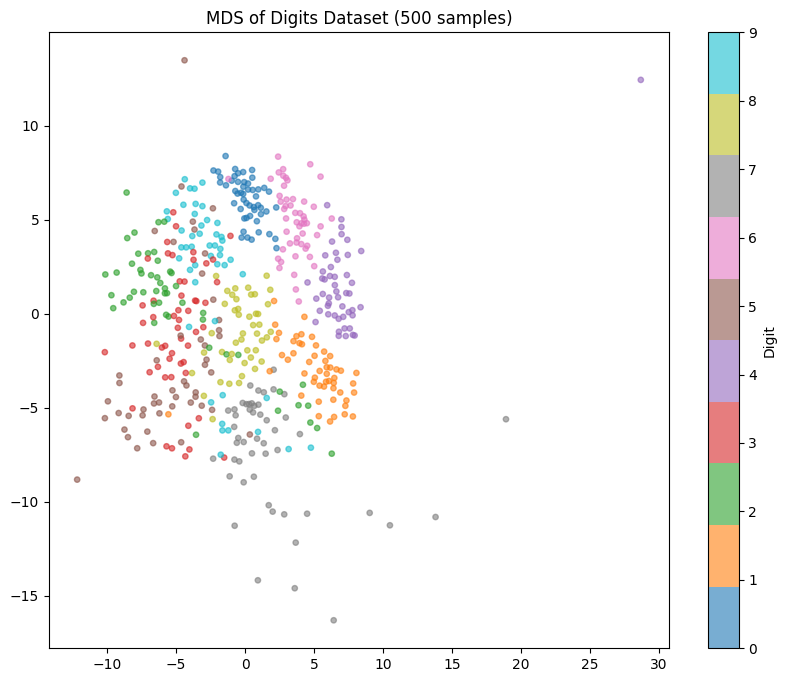

Stress: 1165564.46


In [24]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, random_state=42, normalized_stress="auto")
X_mds = mds.fit_transform(X_digits_scaled[:500])  # MDS is slow, use subset

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_mds[:, 0], X_mds[:, 1], c=y_digits[:500], cmap="tab10", alpha=0.6, s=15)
plt.colorbar(scatter, label="Digit")
plt.title("MDS of Digits Dataset (500 samples)")
plt.show()

print(f"Stress: {mds.stress_:.2f}")


The **stress** metric measures how well the low-dimensional representation preserves the original distances — lower stress means a better fit. MDS is particularly useful when you have a precomputed distance matrix rather than raw features.

### ISOMAP: Isometric Mapping

ISOMAP extends MDS by using **geodesic distances** instead of straight-line (Euclidean) distances. Geodesic distances travel along the surface of the data manifold, which makes ISOMAP great for data that lies on a curved surface.

Think of it this way: on a globe, the straight-line distance between New York and London goes through the Earth. But the *geodesic* distance follows the surface — that's the distance ISOMAP preserves.


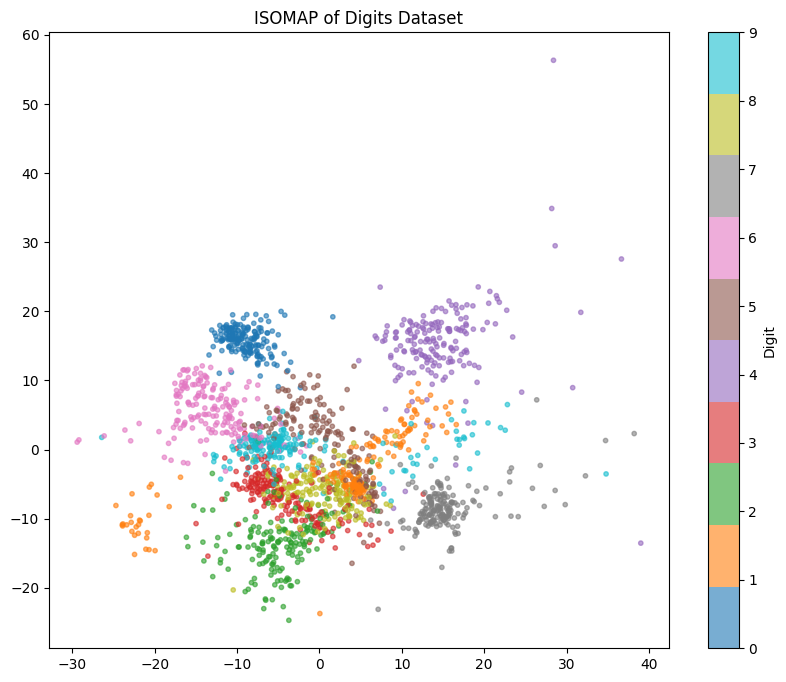

In [25]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2, n_neighbors=10)
X_isomap = isomap.fit_transform(X_digits_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_isomap[:, 0], X_isomap[:, 1], c=y_digits, cmap="tab10", alpha=0.6, s=10)
plt.colorbar(scatter, label="Digit")
plt.title("ISOMAP of Digits Dataset")
plt.show()


ISOMAP works by:

1. Building a **k-nearest-neighbor graph** on the data
2. Computing shortest paths (geodesic distances) through this graph
3. Applying classical MDS to these geodesic distances

The `n_neighbors` parameter controls how local or global the manifold structure is. Too few neighbors can lead to disconnected components; too many can "short-circuit" the manifold.

### Fisher's Linear Discriminant (LDA as Dimensionality Reduction)

It's worth briefly mentioning **Linear Discriminant Analysis (LDA)**. While technically a supervised method (it uses class labels), LDA is often discussed alongside dimensionality reduction techniques because it projects data onto axes that **maximize class separability**.

Unlike PCA which maximizes variance regardless of class labels, LDA finds directions that best separate the classes. If you have labeled data and want to reduce dimensions while preserving class information, LDA can be more effective than PCA.


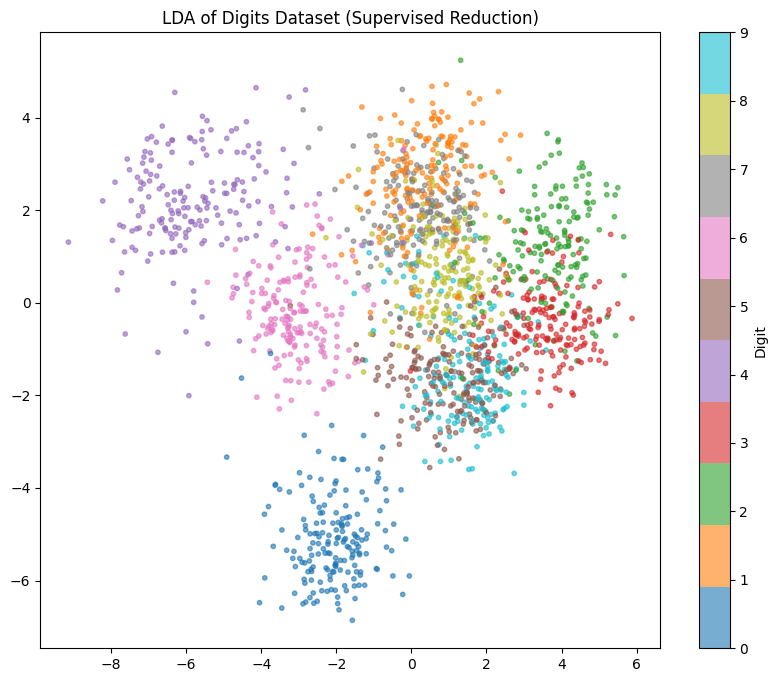

In [28]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_digits_scaled, y_digits)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y_digits, cmap="tab10", alpha=0.6, s=10)
plt.colorbar(scatter, label="Digit")
plt.title("LDA of Digits Dataset (Supervised Reduction)")
plt.show()


The key trade-off: LDA requires labels (so it's not truly unsupervised), but when labels are available, it often produces better separation than PCA.

## Choosing the Right Method

With so many options, how do you decide which technique to use? Here's a practical guide:

### Clustering Method Selection

| Scenario | Recommended Method |
|---|---|
| You know the number of clusters | K-Means |
| Clusters have arbitrary shapes | DBSCAN |
| You want a hierarchy of clusters | Hierarchical Clustering |
| You need soft (probabilistic) assignment | GMM |
| Data has lots of noise/outliers | DBSCAN |
| Clusters are spherical and similar-sized | K-Means |

### Dimensionality Reduction Selection

| Scenario | Recommended Method |
|---|---|
| Quick linear reduction / preprocessing | PCA |
| Visualization of cluster structure | t-SNE |
| Preserving global distances | MDS |
| Data lies on a curved manifold | ISOMAP |
| Supervised + reduction (labeled data) | LDA |

A common and effective workflow is to use **PCA for preprocessing** (reducing to ~50 dimensions) and then **t-SNE for visualization** (reducing to 2D). This gives you the best of both worlds — PCA handles the computational heavy lifting, and t-SNE reveals the fine structure.


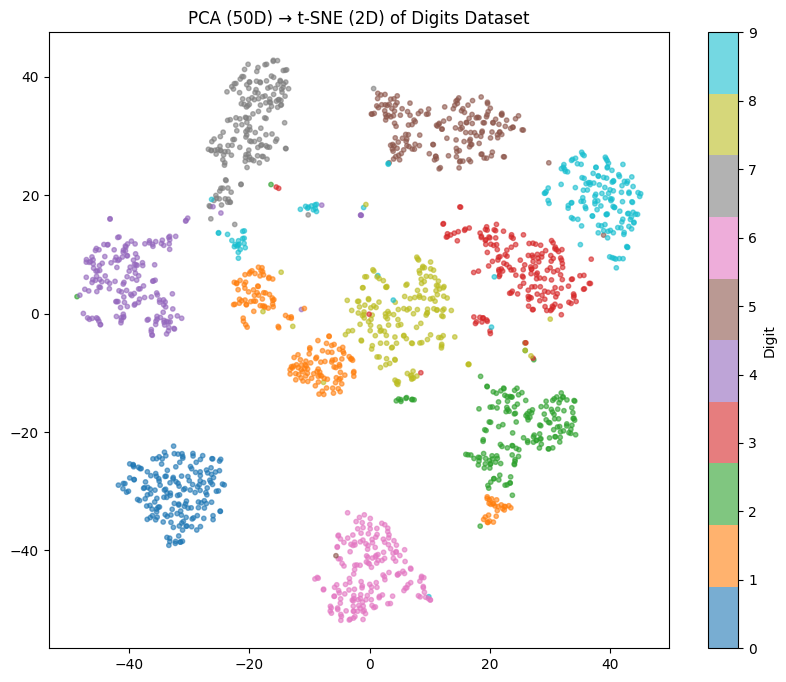

In [29]:
pca_50 = PCA(n_components=50, random_state=42)
X_pca50 = pca_50.fit_transform(X_digits_scaled)

tsne_after_pca = TSNE(n_components=2, perplexity=30, random_state=42)
X_combined = tsne_after_pca.fit_transform(X_pca50)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_combined[:, 0], X_combined[:, 1], c=y_digits, cmap="tab10", alpha=0.6, s=10)
plt.colorbar(scatter, label="Digit")
plt.title("PCA (50D) → t-SNE (2D) of Digits Dataset")
plt.show()


## Summary

In this lesson, you've explored the rich landscape of unsupervised learning. Here are the key takeaways:

- **Unsupervised learning** finds structure in data without labels — it's about discovering patterns, not predicting outcomes
- **K-Means** is fast and simple but requires specifying K and assumes spherical clusters; use the elbow method and silhouette score to choose K
- **Hierarchical clustering** builds a dendrogram and doesn't require pre-specifying K; Ward linkage is often a good default
- **DBSCAN** finds clusters of arbitrary shape, handles noise, and doesn't need K — but requires tuning `eps` and `min_samples`
- **Gaussian Mixture Models** provide soft (probabilistic) cluster assignments using the EM algorithm; use BIC for model selection
- **PCA** is the go-to linear dimensionality reduction method; use explained variance to choose the number of components
- **t-SNE** is excellent for visualization but shouldn't be used for preprocessing; cluster distances in t-SNE plots can be misleading
- **MDS** preserves pairwise distances; **ISOMAP** extends this to curved manifolds using geodesic distances
- **LDA** is a supervised dimensionality reduction method that maximizes class separability

In the next lesson, you'll explore **reinforcement learning** — a completely different paradigm where agents learn by interacting with an environment and receiving rewards. Get ready for a shift in thinking!
